In [8]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from glob import glob
from os.path import join, abspath

## Load Data: Realistic Refill (1.0 tokens/s = 60 tokens/min)

In [9]:
DATA_DIR_REFILL = abspath("../data/both_countermeasures_logs_refill")

def load_from_json(json_path):
    return json.loads(open(json_path).read())

def load_sim_results(json_path, attack_times):
    res = load_from_json(json_path)
    
    # Pretty-format the adversary-controlled share of HSDirs
    h = "-1"
    if res["n_adv_hsdirs"] == 1:
        h = "1/6"
    elif res["n_adv_hsdirs"] == 2:
        h = "1/3"
    elif res["n_adv_hsdirs"] == 6:
        h = "1"
    
    b = "%d%%" % (100 * float(res["adv_bw_share"]))
    tb_iv = res["n_initial_tokens"]
    tb_refill = res["token_refill_rate"]
    vanguardslite_enabled = res.get("vanguardslite_enabled", False)
    
    for timestamp in res["attack_durations"]:
        attack_times.append((h, b, tb_iv, tb_refill, vanguardslite_enabled, timestamp))

# Load realistic refill data (1.0 tokens/s = 60 tokens/min)
attack_times_realistic = []
for json_path in glob(join(DATA_DIR_REFILL, "time_to_double_comp_*_1.000.json")):
    load_sim_results(json_path, attack_times_realistic)

print(f"Loaded {len(attack_times_realistic)} samples with refill_rate=1.0 (60 tokens/min)")

Loaded 600 samples with refill_rate=1.0 (60 tokens/min)


## Create DataFrame

In [10]:
df_realistic = pd.DataFrame(
    attack_times_realistic,
    columns=["h", "b", "tb_iv", "tb_refill", "vanguardslite_enabled", "attack_duration"]
)

print("Realistic (60 tok/min) DataFrame shape:", df_realistic.shape)
print("\nUnique initial tokens:")
print(f"  {sorted(df_realistic['tb_iv'].unique())}")

Realistic (60 tok/min) DataFrame shape: (600, 6)

Unique initial tokens:
  [np.int64(5), np.int64(10), np.int64(15)]


## Summary Statistics

In [11]:
pd.options.display.float_format = "{:,.2f}".format

print("Summary Statistics: Realistic Refill (60 tokens/min)")
print("=" * 80)

summary = df_realistic.groupby(["h", "tb_iv"]).attack_duration.describe(
    percentiles=[0.25, 0.50, 0.90, 0.95, 0.99]
)
print(summary)

Summary Statistics: Realistic Refill (60 tokens/min)
           count  mean   std  min   25%   50%   90%    95%    99%    max
h   tb_iv                                                               
1/3 5     100.00 23.06 14.97 2.18 10.10 21.00 42.49  46.69  67.18  73.90
    10    100.00 20.04 19.62 1.43  6.35 13.41 45.08  60.77  85.77 100.13
    15    100.00 15.50 14.97 1.56  3.82 11.04 32.19  43.69  74.26  74.99
1/6 5     100.00 39.85 31.81 1.34 15.74 29.14 87.22  99.83 137.65 155.28
    10    100.00 44.79 35.25 2.30 19.67 36.84 84.59 104.27 151.68 181.74
    15    100.00 35.71 27.78 1.95 14.04 32.61 72.73  84.57 113.96 121.43


## Compare with Unrealistic Refill (6 tokens/min)

In [12]:
# Add scenario labels
df_realistic["scenario"] = "Realistic (60 tok/min)"

print(f"Total: {len(df_realistic)} samples")

Total: 600 samples


## Visualization: ECDF Comparison

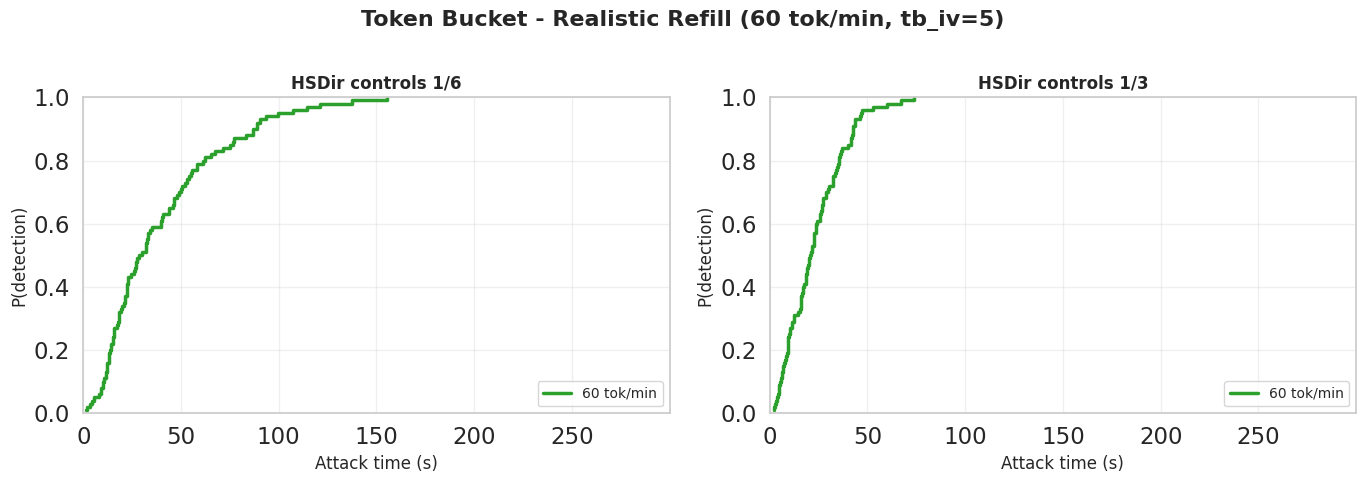

In [13]:
SIMULATION_DURATION = 299.9

# Filter for h=1/6 and h=1/3
df_plot = df_realistic[(df_realistic["h"].isin(["1/6", "1/3"])) & (df_realistic["tb_iv"] == 5)]

sns.set()
sns.set(style="whitegrid", font_scale=1.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Token Bucket - Realistic Refill (60 tok/min, tb_iv=5)", fontsize=16, fontweight="bold")

for idx, h_val in enumerate(["1/6", "1/3"]):
    ax = axes[idx]
    
    # Realistic (60 tokens/min)
    data_realistic = df_plot[
        (df_plot["h"] == h_val)
    ]["attack_duration"].values
    
    if len(data_realistic) > 0:
        sorted_real = np.sort(data_realistic)
        ax.step(sorted_real, np.arange(1, len(sorted_real) + 1) / len(sorted_real),
                where='post', label="60 tok/min", linewidth=2.5, color="tab:green")
    
    ax.set_xlim(0, SIMULATION_DURATION)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Attack time (s)", fontsize=12)
    ax.set_ylabel("P(detection)", fontsize=12)
    ax.set_title(f"HSDir controls {h_val}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

## Key Metrics Table

In [14]:
print("\n" + "="*80)
print("Summary Statistics: Realistic Refill (60 tok/min)")
print("="*80 + "\n")

pd.options.display.float_format = "{:,.2f}".format

summary_stats = df_realistic.groupby(["h", "tb_iv"]).attack_duration.describe(
    percentiles=[0.25, 0.50, 0.90, 0.95, 0.99]
)
print(summary_stats)


Summary Statistics: Realistic Refill (60 tok/min)

           count  mean   std  min   25%   50%   90%    95%    99%    max
h   tb_iv                                                               
1/3 5     100.00 23.06 14.97 2.18 10.10 21.00 42.49  46.69  67.18  73.90
    10    100.00 20.04 19.62 1.43  6.35 13.41 45.08  60.77  85.77 100.13
    15    100.00 15.50 14.97 1.56  3.82 11.04 32.19  43.69  74.26  74.99
1/6 5     100.00 39.85 31.81 1.34 15.74 29.14 87.22  99.83 137.65 155.28
    10    100.00 44.79 35.25 2.30 19.67 36.84 84.59 104.27 151.68 181.74
    15    100.00 35.71 27.78 1.95 14.04 32.61 72.73  84.57 113.96 121.43
